# Hillsborough County Parcel Comp Analysis: Modeling and Analysis

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_parquet("../data/processed/cleaned.parquet")
df.head()

,FOLIO,SITE_ZIP,tBEDS,tBATHS,tSTORIES,tUNITS,tBLDGS,HEAT_AR,ACREAGE,LU_GRP,S_AMT,S_YEAR
0,0000080100,33556,3.0,2.0,2.0,1.0,1.0,2617.0,5.06,SINGLE FAMILY,360000.0,2015
1,0000090100,33556,3.0,2.5,1.0,1.0,1.0,1572.0,4.44,SINGLE FAMILY,750000.0,2021
2,0000100008,33556,3.0,2.0,2.0,1.0,1.0,3123.0,2.77,SINGLE FAMILY,87000.0,2015
3,0000100008,33556,3.0,2.0,2.0,1.0,1.0,3123.0,2.77,SINGLE FAMILY,425000.0,2015
4,0000100009,33556,4.0,3.5,2.0,1.0,1.0,3258.0,1.36,SINGLE FAMILY,799900.0,2022


Split the data into testing and training sets

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['S_AMT', 'S_AMT_transformed'], errors='ignore')
y = df['S_AMT']
X_train, X_test, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=42)


Since the data isn't a normal distribution, we need to use a Box-Cox to determine the optimal $\lambda$ value and transform the training data

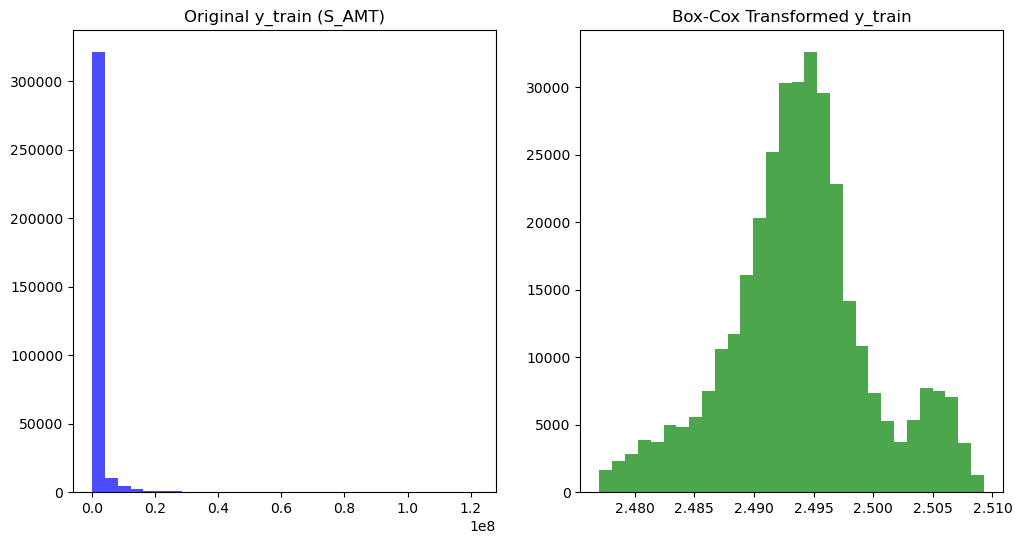

Optimal Box-Cox lambda: -0.398


In [ ]:
# Transform the data using Box-Cox transformation
from scipy.stats import boxcox

y_train_transformed, lambda_value = boxcox(y_train_orig)

# 5. Visualize transformation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(y_train_orig, bins=30, color='blue', alpha=0.7)
ax[0].set_title('S_AMT')
ax[1].hist(y_train_transformed, bins=30, color='green', alpha=0.7)
ax[1].set_title('Box-Cox Transformed S_AMT')
plt.show()
print(f"Optimal Box-Cox lambda: {lambda_value:.3f}")


In [ ]:
# Preprocessing for numerical and categorical features
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Feature groups
num_cols = ['tBEDS', 'tBATHS', 'tSTORIES', 'tUNITS', 'tBLDGS', 'HEAT_AR', 'ACREAGE']
cat_cols = ['SITE_ZIP', 'LU_GRP']

# Preprocessing steps
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

Setup the RandomizedSearchCV for finding the optimal parameters

In [ ]:
# Setup pipelines for different base models
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

# Define pipelines for different base models
pipelines = {
    'linear': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'elastic': Pipeline([('prep', preprocessor), ('model', ElasticNet())]),
    'rf': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
    'ann': Pipeline([('prep', preprocessor), ('model', MLPRegressor(random_state=42))]),
    'lgbm': Pipeline([('prep', preprocessor), ('model', LGBMRegressor(random_state=42))])
}


In [ ]:


# Define param grids per model
param_grids = {
    'linear': {},
    'elastic': {
        'model__alpha': [0.001, 0.005, 0.01, 0.05],
        'model__l1_ratio': [0.01, 0.1, 0.2, 0.3]
    },
    'rf': {
        'model__n_estimators': [375, 400, 425],
        'model__max_depth': [20, 25, 30]
    },
    'ann': {
        'model__hidden_layer_sizes': [(50,), (64,), (50, 50)],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate_init': [0.0005, 0.001],
        'model__max_iter': [300, 500],
        'model__early_stopping': [True]
    },
    'lgbm': {
        'model__n_estimators': [275, 300, 325],
        'model__learning_rate': [0.03, 0.05, 0.07],
        'model__num_leaves': [56, 64, 72],
        'model__min_child_samples': [10, 20, 30],
        'model__subsample': [0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.8, 0.9, 1.0],
        'model__reg_alpha': [0.0, 0.1, 0.5],
        'model__reg_lambda': [0.0, 0.1, 0.5]
    }
}


Run the tune the models and report the error using Root Mean Squared Error based on the following formula
$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

In [ ]:
# Perform hyperparameter tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

best_models = {}

for name, pipeline in pipelines.items():
    print(f"\nTuning {name}...")
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=5,
        cv=5,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train_transformed)
    best_models[name] = search.best_estimator_
    print(f"Best RMSE on transformed data: {-search.best_score_:.10f}")


Tuning linear...


/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=5. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best RMSE on transformed data: 0.0050849981

Tuning elastic...
Best RMSE on transformed data: 0.0051152830

Tuning rf...


/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RMSE on transformed data: 0.0044143399

Tuning ann...
Best RMSE on transformed data: 0.0066277196

Tuning lgbm...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 272585, number of used features: 60
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 272584, number o

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 272585, number of used features: 60
[LightGBM] [Info] Start training from score 2.493825
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 272584, number of used features: 60
[LightGBM] [Info] Start training from score 2.493829
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 272585, number of used features: 60
[LightGBM] [Info] Start training from score 2.493816
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 272585, number of used features: 60
[LightGBM] [Info] Start training from score 2.493824
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007809 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bi

/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/bofethe/miniconda3/envs/parcels/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have v

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 340731, number of used features: 60
[LightGBM] [Info] Start training from score 2.493828
Best RMSE on transformed data: 0.0044979926


In [43]:
best_models['lgbm']

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tBEDS', 'tBATHS',
                                                   'tSTORIES', 'tUNITS',
                                                   'tBLDGS', 'HEAT_AR',
                                                   'ACREAGE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SITE_ZIP', 'LU_GRP'])])),
                ('model',
                 LGBMRegressor(learning_rate=0.05, n_estimators=300,
                               num_leaves=64, random_state=42))])

In [30]:
from scipy.special import inv_boxcox
from sklearn.metrics import root_mean_squared_error

# Dictionary to store RMSE values
rmse_scores = {}

for name, model in best_models.items():
    print(f"\nEvaluating {name}...")

    # Predict on test set (Box-Cox scale)
    y_pred_transformed = model.predict(X_test)

    # Inverse Box-Cox to return to dollar scale
    y_pred_orig = inv_boxcox(y_pred_transformed, lambda_value)

    # Compute RMSE using true (untransformed) y_test
    rmse = root_mean_squared_error(y_test_orig, y_pred_orig)
    rmse_scores[name] = rmse

    print(f"RMSE: ${rmse:,.2f}")



Evaluating linear...
RMSE: $5,852,024.04

Evaluating elastic...
RMSE: $5,855,290.20

Evaluating rf...
RMSE: $5,675,361.14

Evaluating ann...


ValueError: Input contains NaN.